# Sugar-Seasonality — a quantitative teardown 🔬
### A 12-cell Bonferroni month table · a tight-vs-crush Welch/HAC split · a block-bootstrap CI · the ETF-vs-futures roll-drag test · a costed calendar timer · a coin-flip hit-rate test · a 20-seed synthetic null

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_a_coin%3F: Busted](https://img.shields.io/badge/Beats_a_coin%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **raw sugar carries a pre-harvest-tight premium that decays into the Brazilian crush** — has a real agronomic mechanism (Brazil's and India's crush seasons) and plenty of trading-floor conviction behind it. The job here is to test it on the instrument a retail account can actually hold, with the multiple-testing correction a 12-cell month grid demands.

> ⚠️ **Data note.** CANE daily adjusted closes + SB=F daily raw closes, yfinance, 2011-10-03 → 2026-06-30 (176 monthly observations per series); **hardcoded Brazil/India crush windows** (facts, no network). No survivorship (single continuously-listed tickers). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprints `c0c35fdc0e66` / `88229d212e57`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from sugar_seasonality import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    ETF, FUT = data.load_real()
    MONTHLY = st.monthly_log_returns(ETF)
    FUT_MONTHLY = st.monthly_log_returns(FUT)
else:
    ETF = FUT = MONTHLY = FUT_MONTHLY = None
print("real cache present:", HAVE_REAL, "| months on tape:", (0 if MONTHLY is None else len(MONTHLY)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2011-10-03', 'end': '2026-06-30', 'n_months': 176, 'bonf_crit': 3.47, 'bonf_survive': 0, 'bonf_n': 12, 'month': {1: (0.27, 15, 0.17, 0.18), 2: (0.05, 15, 0.04, 0.07), 3: (-1.31, 15, -0.48, -0.47), 4: (-0.68, 15, -0.3, -0.31), 5: (-2.11, 15, -1.8, -1.9), 6: (0.23, 15, 0.17, 0.25), 7: (-1.29, 14, -0.85, -1.26), 8: (-0.46, 14, -0.31, -0.31), 9: (1.44, 14, 0.96, 1.5), 10: (-0.03, 14, -0.02, -0.02), 11: (-0.63, 15, -0.52, -0.71), 12: (-1.76, 15, -1.15, -1.12)}, 'best_month': 9, 'best_mean': 1.44, 'best_t': 1.36, 'best_n': 14, 'worst_month': 5, 'worst_mean': -2.11, 'worst_t': -1.35, 'worst_n': 15, 'tight_mean': -0.33, 'tight_n': 45, 'crush_mean': -0.96, 'crush_n': 59, 'spread': 0.63, 'spread_t': 0.46, 'ci_lo': -1.89, 'ci_hi': 2.98, 'ci_boot': 5000, 'etf_bps': -53.4, 'fut_bps': -33.3, 'drag_bps': -20.1, 'drag_t': -0.8, 'drag_n': 176, 'bh_sharpe': -0.29, 'bh_cagr': -8.5, 'tg_sharpe': 0.16, 'tg_cagr': 1.2, 'tn_sharpe': 0.14, 'tn_cagr': 0.8, 'hit_k': 61, 'hit_n': 104, 'hit_rate': 58.7, 'hit_lo': 49.0, 'hit_hi': 67.6, 'hit_t': 0.6, 'syn_null_mean': 0.23, 'syn_null_sd': 1.01, 'syn_null_fire': 0, 'syn_planted_t': 4.73, 'syn_planted_pct': 12.0, 'fp_cane': 'c0c35fdc0e66', 'fp_sb': '88229d212e57'}


real cache present: True | months on tape: 176


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | tight-vs-crush spread **+0.63%/mo**, Welch **t = +0.46**, bootstrap CI **[-1.89%, +2.98%]**; **0/12** month cells clear the Bonferroni bar (\|t\| ≥ 3.47) |
| **Tradability** | `MIRAGE` | roll drag **-20.1 bps/mo** (t = -0.80, uncertified); timer net Sharpe **+0.14** vs buy-and-hold **-0.29** |
| **Beats a coin?** | `BUSTED` | active-leg hit rate **61/104 = 58.7%** (Wilson [49.0%, 67.6%]), t = 0.60 |

> 💡 In plain words: the crush calendar is real agronomics; the ETF tape shows no certified trace of it, and what little the timer earns is a cash-drag illusion, not skill.

## 1 · The claim, steelmanned

Let $r_t$ be CANE's monthly log return and $T, C \subset \{1..12\}$ the claimed pre-harvest-tight (Jan-Mar) and crush-glut (Apr-Jul) month sets, chosen from the hardcoded Brazil/India crush calendar. The claims:

- **H₁ (level).** $E[r_t \mid m_t \in T] \gg E[r_t \mid m_t \in C]$ — the winter months systematically outperform the early-crush months.
- **H₂ (concentration).** The seasonal is a genuine calendar effect, not one lucky month out of the 12 cells on the board.
- **H₃ (tradability).** A calendar-known long-tight/short-crush timer on the *ETF* earns net of costs and beats a coin on its active legs.
- **H₄ (roll).** Whatever the raw futures curve shows, the ETF the retail account actually holds captures most of it (the roll doesn't eat the edge).

We find **H₁ rejected** (t = +0.46, right sign but noise-sized), **H₂ rejected** (0/12 Bonferroni survivors, 0/12 even clear the naive |t| ≥ 2 line), **H₃ rejected** (58.7% active-leg hit rate, uncertified) and **H₄ inconclusive but adverse** (a nominal, uncertified drag against the long-tight leg).

## 2 · So what? — inference design

Calendar months within a year are **not** independent draws (a Brazilian drought or an early/late Indian monsoon is autocorrelated across adjacent months), so every per-month test reports both a naive one-sample *t* and a **Newey-West (HAC)** *t*. Testing 12 months at once means the honest bar is **Bonferroni**-corrected: $\alpha/12 \approx 0.0042$, which at $df \approx 13$ needs $|t| \ge 3.47$ — notably stricter than the naive $|t| \ge 2$, though (unlike study 648's 3-grain, 36-cell grid) this single-instrument test only needs the /12 bar, not /36. The tight-vs-crush headline uses a **Welch** two-sample *t* (unequal variances, unequal group sizes by construction) plus a **circular block-bootstrap** (12-month blocks, respecting the annual seasonal structure) for a distribution-free CI on the spread.

## 3 · How we'd know — the protocol

- **Tape.** CANE adjusted closes + SB=F raw closes, 2011-10-03 → 2026-06-30, resampled to **176 monthly observations**. As-of 2026-06-30 (last complete month).
- **Calendar.** Hardcoded Brazil Center-South crush (Apr-Nov), India crush (Oct-Apr) and the claimed pre-harvest-tight (Jan-Mar) / crush-glut (Apr-Jul) test windows (`SUGAR_CALENDAR` in `data.py`) — facts, not a fit.
- **Headline.** Per-month naive + HAC *t* (12 cells, Bonferroni-corrected); best/worst month Welch *t* vs rest; tight-vs-crush Welch *t* with a 5,000-draw block-bootstrap CI.
- **Execution (calendar-known).** The seasonal timer's position is set from the fixed crush calendar alone — no signal-to-trade lag is needed, because the calendar repeats every year and is known at the start of it.
- **Costs.** 4 one-way legs/yr × 10 bps × NAV, spread evenly across the 12 months.
- **Roll cross-check.** CANE monthly return minus the roll-naive SB=F-splice monthly return, one-sample *t* of the gap — sizes what the ETF's own mechanics already take before any calendar math starts.
- **Control.** i.i.d. synthetic monthly-return world, planted tight/crush spread knob; the null must not fire across 20 seeds.

## 4 · The teardown

### 4a · The 12-cell month table and the Bonferroni bar

Per-month naive + HAC *t*-stats. The Bonferroni-corrected bar for 12 simultaneous tests dwarfs the naive |t| ≥ 2 line.

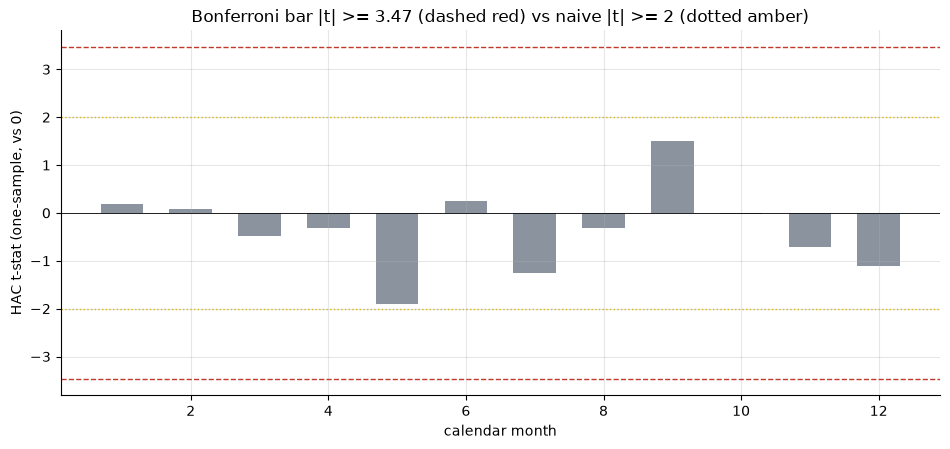

cells clearing Bonferroni: 0/12   cells clearing naive |t|>=2: 0/12


In [2]:
if HAVE_REAL:
    crit = st.bonferroni_crit_t(12, df=13)
    ms = st.month_stats(MONTHLY)
    hac = ms['tstat_hac'].to_numpy()
else:
    crit = R['bonf_crit']
    hac = [R['month'][m][3] for m in range(1, 13)]
fig, ax = plt.subplots(figsize=(9.6, 4.6))
cols = [RED if abs(v) >= crit else GREY for v in hac]
ax.bar(range(1, 13), hac, color=cols, width=.62)
ax.axhline(crit, ls='--', c=RED, lw=1); ax.axhline(-crit, ls='--', c=RED, lw=1)
ax.axhline(2, ls=':', c=AMBER, lw=1); ax.axhline(-2, ls=':', c=AMBER, lw=1)
ax.axhline(0, c='k', lw=.6)
ax.set_xlabel('calendar month'); ax.set_ylabel('HAC t-stat (one-sample, vs 0)')
ax.set_title(f'Bonferroni bar |t| >= {crit:.2f} (dashed red) vs naive |t| >= 2 (dotted amber)')
plt.tight_layout(); plt.show()
n_survive = sum(int(abs(v) >= crit) for v in hac)
n_naive = sum(int(abs(v) >= 2) for v in hac)
print(f'cells clearing Bonferroni: {n_survive}/12   cells clearing naive |t|>=2: {n_naive}/12')

**0/12** cells clear the Bonferroni bar (|t| ≥ 3.47) — and, notably, **none clear even the naive |t| ≥ 2 line either**. The largest-magnitude cell is May (mean -2.11%, t<sub>HAC</sub> = -1.90) — inside the claimed crush window, pointing the claimed (negative) direction, but short of even nominal significance.

### 4b · Best/worst month and tight-vs-crush

Welch *t* of the single best/worst month vs every other month pooled, and of the claimed tight-vs-crush window.

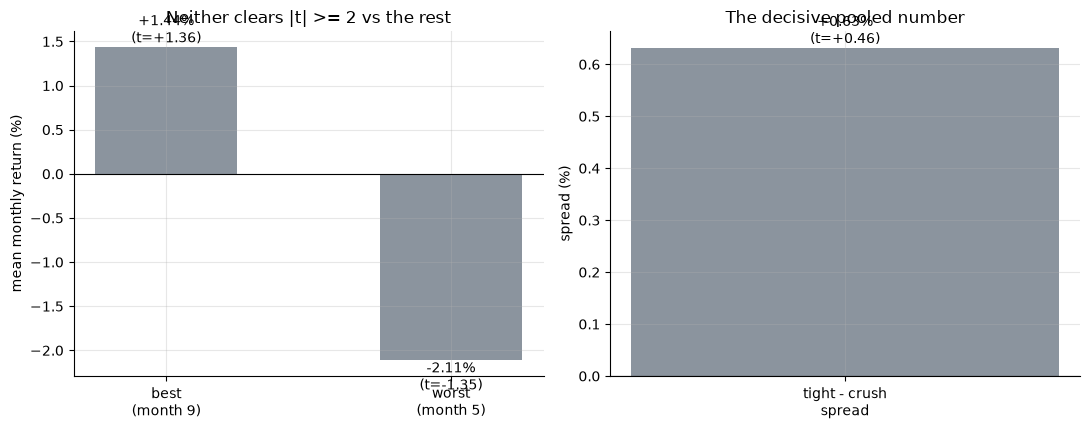

best month t=+1.36  worst month t=-1.35  spread t=+0.46


In [3]:
if HAVE_REAL:
    bw = st.best_worst_vs_rest(MONTHLY)
    tc = st.tight_crush_tstat(MONTHLY, data.TIGHT_MONTHS, data.CRUSH_MONTHS)
    spread, spread_t = tc['spread']*100, tc['t']
else:
    bw = {'best_month': R['best_month'], 'best_mean': R['best_mean'], 'best_t': R['best_t'],
          'worst_month': R['worst_month'], 'worst_mean': R['worst_mean'], 'worst_t': R['worst_t']}
    spread, spread_t = R['spread'], R['spread_t']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.4))
labels = [f"best\n(month {bw['best_month']})", f"worst\n(month {bw['worst_month']})"]
vals = [bw['best_mean']*100 if HAVE_REAL else bw['best_mean'],
        bw['worst_mean']*100 if HAVE_REAL else bw['worst_mean']]
ts = [bw['best_t'], bw['worst_t']]
a1.bar(labels, vals, color=[RED if abs(t)>=2 else GREY for t in ts], width=.5)
for i,(v,t) in enumerate(zip(vals, ts)): a1.annotate(f'{v:+.2f}%\n(t={t:+.2f})',(i,v),
    ha='center', va='bottom' if v>=0 else 'top')
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('mean monthly return (%)')
a1.set_title('Neither clears |t| >= 2 vs the rest')
a2.bar(['tight - crush\nspread'], [spread], color=RED if abs(spread_t)>=2 else GREY, width=.4)
a2.annotate(f'{spread:+.2f}%\n(t={spread_t:+.2f})', (0, spread), ha='center',
    va='bottom' if spread>=0 else 'top')
a2.axhline(0, c='k', lw=.8); a2.set_ylabel('spread (%)')
a2.set_title('The decisive pooled number')
plt.tight_layout(); plt.show()
print(f'best month t={bw["best_t"]:+.2f}  worst month t={bw["worst_t"]:+.2f}  spread t={spread_t:+.2f}')

> 💡 In plain words: the best month (September, +1.44%, t = +1.36) and worst month (May, -2.11%, t = -1.35) are both inside |t| < 2 of the rest of the calendar. The pooled tight-vs-crush spread (+0.63%, t = +0.46) is closer to zero than either individual month.

### 4c · The bootstrap CI on the decisive spread

A circular block-bootstrap (12-month blocks, respecting the annual seasonal structure) gives a distribution-free CI on the tight-minus-crush spread.

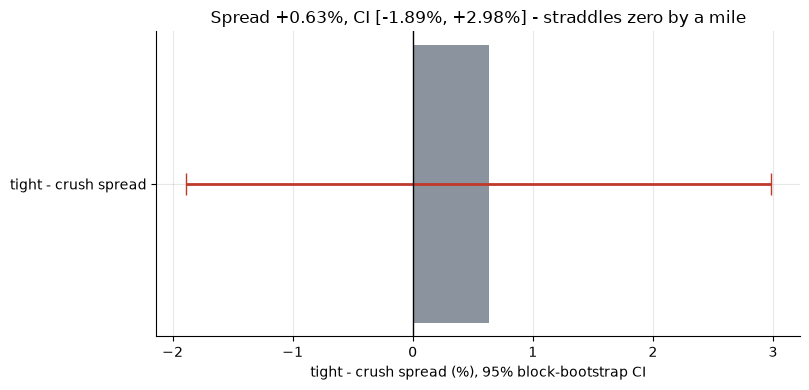

pooled spread +0.63%  CI [-1.89%, +2.98%]


In [4]:
if HAVE_REAL:
    ci = st.spread_bootstrap_ci(MONTHLY, data.TIGHT_MONTHS, data.CRUSH_MONTHS)
    spread, lo, hi = tc['spread']*100, ci['lo']*100, ci['hi']*100
else:
    spread, lo, hi = R['spread'], R['ci_lo'], R['ci_hi']
fig, ax = plt.subplots(figsize=(8.2, 4.0))
ax.barh(['tight - crush spread'], [spread], color=GREY, height=.4)
ax.errorbar([spread], ['tight - crush spread'], xerr=[[spread-lo],[hi-spread]],
            fmt='none', ecolor=RED, capsize=8, lw=2)
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('tight - crush spread (%), 95% block-bootstrap CI')
ax.set_title(f'Spread {spread:+.2f}%, CI [{lo:+.2f}%, {hi:+.2f}%] - straddles zero by a mile')
plt.tight_layout(); plt.show()
print(f'pooled spread {spread:+.2f}%  CI [{lo:+.2f}%, {hi:+.2f}%]')

> 💡 In plain words: the CI width (roughly 4.9 points) is about 8x the point estimate itself. H₁ is rejected — not "weak," genuinely indistinguishable from zero on this tape.

### 4d · The ETF's own roll — the 'contango' caveat, sized

CANE's monthly return minus the roll-naive SB=F-splice monthly return, one-sample *t* of the gap.

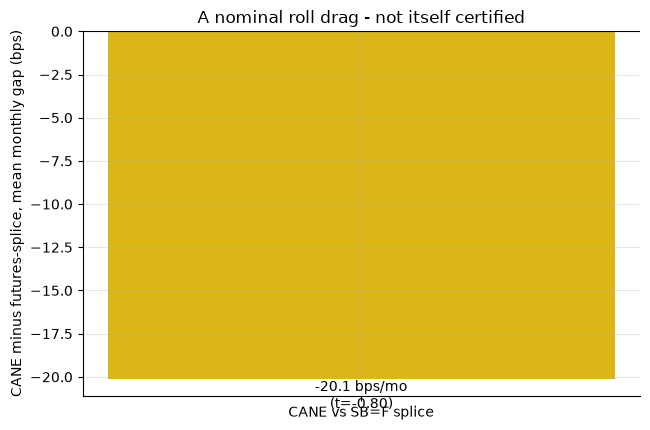

drag -20.1 bps/mo  t=-0.80


In [5]:
if HAVE_REAL:
    drag = st.roll_drag(MONTHLY, FUT_MONTHLY)
    d, dt = drag['drag_bps'], drag['t']
else:
    d, dt = R['drag_bps'], R['drag_t']
fig, ax = plt.subplots(figsize=(6.6, 4.4))
ax.bar(['CANE vs SB=F splice'], [d], color=RED if abs(dt)>=2 else AMBER, width=.4)
ax.annotate(f'{d:+.1f} bps/mo\n(t={dt:+.2f})', (0, d), ha='center', va='top' if d<0 else 'bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('CANE minus futures-splice, mean monthly gap (bps)')
ax.set_title('A nominal roll drag - not itself certified')
plt.tight_layout(); plt.show()
print(f'drag {d:+.1f} bps/mo  t={dt:+.2f}')

> 💡 In plain words: CANE's drag (-20.1 bps/mo, t = -0.80) works against a long-tight bet in direction, but does **not** itself clear |t| ≥ 2 — unlike study 648's WEAT (certified −90.3 bps/mo, t = −5.09), sugar's roll is not the decisive blow here. The seasonal itself is already indistinguishable from noise before any roll cost is charged.

### 4e · The costed timer and the coin-flip test

Long tight, short crush, cash otherwise (no execution lag — the crush calendar repeats every year); 4 one-way legs/yr × 10 bps × NAV. The honest read isolates the *active* legs from the cash months.

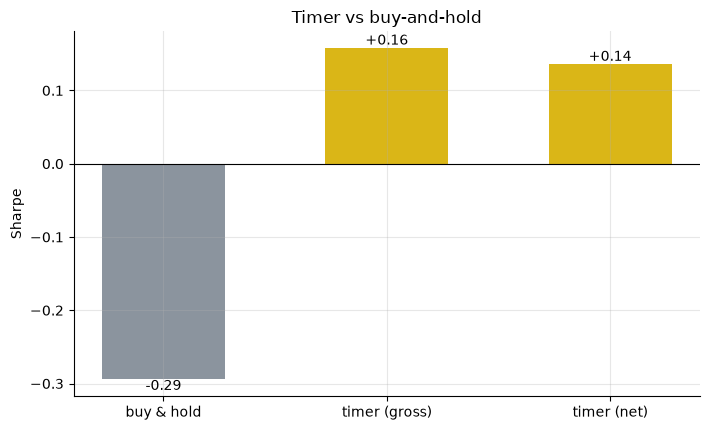

buy&hold -0.29   timer gross +0.16   timer net +0.14


In [6]:
if HAVE_REAL:
    timer = st.seasonal_timer(MONTHLY, data.TIGHT_MONTHS, data.CRUSH_MONTHS)
    net = st.apply_costs(timer, n_trades_per_year=4, cost_bps_one_way=10.0)
    bh, tg, tn = st.summary(MONTHLY)['sharpe'], st.summary(timer)['sharpe'], st.summary(net)['sharpe']
else:
    bh, tg, tn = R['bh_sharpe'], R['tg_sharpe'], R['tn_sharpe']
fig, ax = plt.subplots(figsize=(7.2, 4.4))
ax.bar(['buy & hold', 'timer (gross)', 'timer (net)'], [bh, tg, tn], color=[GREY, AMBER, AMBER], width=.55)
for i, v in enumerate([bh, tg, tn]): ax.annotate(f'{v:+.2f}', (i, v), ha='center', va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('Sharpe'); ax.set_title('Timer vs buy-and-hold')
plt.tight_layout(); plt.show()
print(f'buy&hold {bh:+.2f}   timer gross {tg:+.2f}   timer net {tn:+.2f}')

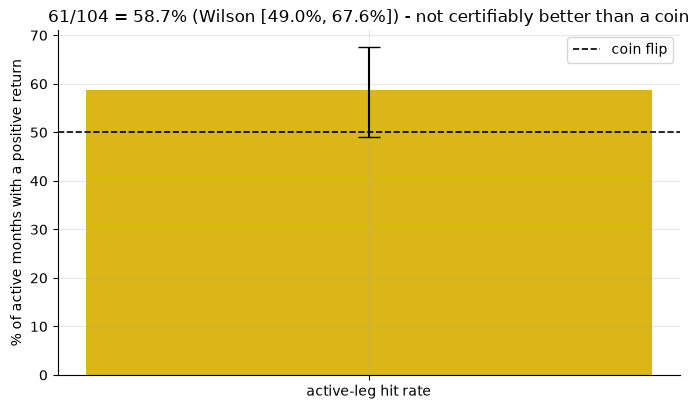

hit rate 61/104 = 58.7%  Wilson [49.0%, 67.6%]  t=+0.60


In [7]:
if HAVE_REAL:
    active = timer[timer != 0.0].dropna()
    x = active.to_numpy()
    k, n = int((x > 0).sum()), len(x)
    rate = k / n
    t = st._one_sample_t(x)
else:
    k, n, rate, t = R['hit_k'], R['hit_n'], R['hit_rate']/100, R['hit_t']
lo, hi = st.wilson_interval(k, n)
fig, ax = plt.subplots(figsize=(7.0, 4.2))
ax.bar(['active-leg hit rate'], [rate*100], color=AMBER if rate >= 0.5 else RED, width=.4)
ax.errorbar([0], [rate*100], yerr=[[(rate-lo)*100],[(hi-rate)*100]], fmt='none', ecolor='k', capsize=8)
ax.axhline(50, ls='--', c='k', lw=1.2, label='coin flip')
ax.set_ylabel('% of active months with a positive return')
ax.set_title(f'{k}/{n} = {rate*100:.1f}% (Wilson [{lo*100:.1f}%, {hi*100:.1f}%]) - not certifiably better than a coin')
ax.legend(); plt.tight_layout(); plt.show()
print(f'hit rate {k}/{n} = {rate*100:.1f}%  Wilson [{lo*100:.1f}%, {hi*100:.1f}%]  t={t:+.2f}')

> 💡 In plain words: the Sharpe bar chart flatters the timer (it's mostly just cash on an already-losing ETF), but the coin-flip test strips that out — on the months the trade is actually live, it wins **58.7%** of the time (Wilson [49.0%, 67.6%]), a point estimate above 50% whose interval still straddles it. Mean per active month is statistically zero (t = 0.60). **H₃ rejected.**

### 4f · Faithful-engine & power control — we know the truth here

Deterministic i.i.d. monthly-return world with a TUNABLE planted tight-premium/crush-discount pair. The null is checked over **20 seeds** — never a single stream.

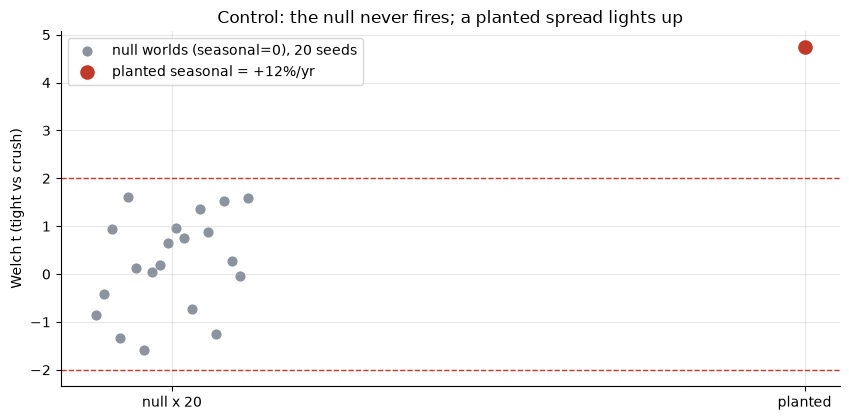

null: mean t = +0.23 (sd 1.01), |t|>=2 in 0/20 seeds  |  planted t = +4.73


In [8]:
null_ts = []
for s_ in range(20):
    df = data.synthetic_world(seasonal=0.0, seed=651 + s_)
    null_ts.append(st.synthetic_detect(df, data.TIGHT_MONTHS, data.CRUSH_MONTHS)['t'])
null_ts = np.asarray(null_ts)
df = data.synthetic_world(seasonal=0.12, seed=651)
planted_t = st.synthetic_detect(df, data.TIGHT_MONTHS, data.CRUSH_MONTHS)['t']
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12, .12, 20), null_ts, color=GREY, s=40,
           label='null worlds (seasonal=0), 20 seeds')
ax.scatter([1], [planted_t], color=RED, s=90, zorder=5, label='planted seasonal = +12%/yr')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('Welch t (tight vs crush)')
ax.set_title('Control: the null never fires; a planted spread lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds  |  planted t = {planted_t:+.2f}')

> 💡 In plain words: across 20 null worlds the detector averages t = +0.23 (sd 1.01) and **never** crosses the bar (0/20); a planted 12%/yr spread reads t = 4.73. The machinery is unbiased — the real-tape t = +0.46 is the genuine article, not a broken detector. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — tight-vs-crush spread **+0.63%/month**, Welch t = **+0.46**, bootstrap CI **[-1.89%, +2.98%]**; **0/12** grid cells clear Bonferroni, and none even clear the weaker naive |t| ≥ 2 line; the nominal direction agrees with the folklore (worst month May, inside the crush window) but every number sits well inside noise.
- **Tradability `MIRAGE`** — CANE's roll drag is a nominal, uncertified **-20.1 bps/month (t = -0.80)** against a long-tight bet; the timer's net Sharpe is **+0.14** vs buy-and-hold's **-0.29**, and the apparent gain is a cash-drag artifact of an already-losing ETF.
- **"Beats a coin?" `BUSTED`** — active-leg hit rate **61/104 = 58.7%** (Wilson [49.0%, 67.6%]), mean per active month t = **0.60**. Not *wrong* about the agronomics existing — wrong that it's still there, tradable, in this ETF, today.

## 6 · Going further

- **The mechanism could still live in the raw futures basis.** This study tests the *ETF*, not the contract-to-contract calendar spread directly. A term-structure study (front vs deferred, calendar-spread level around the crush windows) is the natural sequel, the way study 648's roll-drag test separates the curve from the holder.
- **Weather-year and El Niño clustering could be masking a conditional effect** — a seasonal that only shows up in *drought* years is a different, testable claim; this study deliberately averages across all weather regimes, which is why an unconditional calendar test comes up empty even if a conditional one wouldn't.
- **Dedup map:** [307-coffee-seasonality](../../307-coffee-seasonality/) (a frost tail event, not a crush calendar), [308-cocoa-squeeze](../../308-cocoa-squeeze/) (a squeeze, not a calendar), [648-grain-seasonality](../../648-grain-seasonality/) (the same old-crop/new-crop shape, a different crop family and mechanism) — all reach the same honest `NONE`/`MIRAGE` shape independently.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*